# Customer Purchase & Ad Exposure Modeling  
### Poisson vs Negative Binomial Regression

**Author:** Maha Khalaf  
**Tools:** Python, Pandas, NumPy, StatsModels  

## Project Overview

This project analyzes customer behavior using count models (Poisson and Negative Binomial).  
The goal is to predict the number of purchases/exposures and evaluate which model provides the best fit.

We compare models using:
- Log-Likelihood
- AIC / BIC
- Predictive accuracy

In [7]:
import pandas as pd
import numpy as np
from scipy.optimize import minimize
from scipy.special import factorial
import statsmodels.api as sm
from scipy.optimize import minimize
from scipy.special import gammaln
from scipy.stats import nbinom
from scipy.stats import poisson

#Exploratory Analysis
# Load the billboard.csv dataset
data = pd.read_csv("billboard.csv")

# Inspect the data to understand its structure
print(data)

Y = data['EXPOSURES']  
X = data['PEOPLE']  
X = sm.add_constant(X)  # Add intercept

# Fit the Poisson regression model using MLE
poisson_model = sm.GLM(Y, X, family=sm.families.Poisson()).fit()

# Print the model summary to see estimated parameters
print(poisson_model.summary())



    EXPOSURES  PEOPLE
0           0      48
1           1      37
2           2      30
3           3      24
4           4      20
5           5      16
6           6      13
7           7      11
8           8       9
9           9       7
10         10       6
11         11       5
12         12       5
13         13       3
14         14       3
15         15       2
16         16       2
17         17       2
18         18       1
19         19       1
20         20       2
21         21       1
22         22       1
23         23       1
                 Generalized Linear Model Regression Results                  
Dep. Variable:              EXPOSURES   No. Observations:                   24
Model:                            GLM   Df Residuals:                       22
Model Family:                 Poisson   Df Model:                            1
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:

    Exposure  Predicted_Count
0          0     2.902176e+00
1          1     1.293210e+01
2          2     2.881271e+01
3          3     4.279648e+01
4          4     4.767528e+01
5          5     4.248821e+01
6          6     3.155458e+01
7          7     2.008674e+01
8          8     1.118832e+01
9          9     5.539460e+00
10        10     2.468383e+00
11        11     9.999196e-01
12        12     3.713035e-01
13        13     1.272714e-01
14        14     4.050867e-02
15        15     1.203378e-02
16        16     3.351407e-03
17        17     8.784628e-04
18        18     2.174683e-04
19        19     5.100205e-05
20        20     1.136326e-05
21        21     2.411175e-06
22        22     4.883725e-07
23        23     9.461687e-08


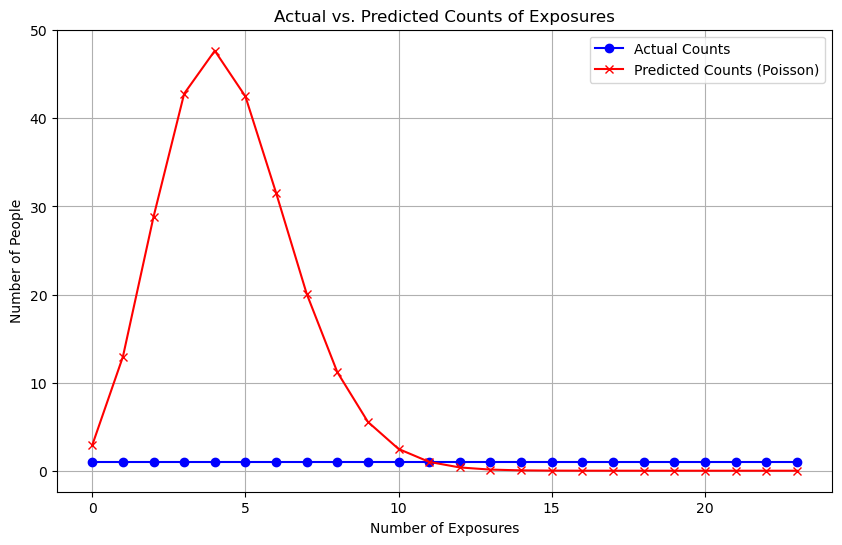

In [8]:
import matplotlib.pyplot as plt

# Calculate the lambda (mean exposures) if not explicitly provided
if 'lambda_mle' not in locals():  # if not already estimated
    lambda_mle = np.sum(data['EXPOSURES'] * data['PEOPLE']) / data['PEOPLE'].sum()

# Predict counts for each exposure level from 0 to 23
max_exposure = 23
predicted_counts = []

# Calculate the total number of observations/people
total_population = data['PEOPLE'].sum()

for k in range(0, max_exposure + 1):
    prob = poisson.pmf(k, lambda_mle)  # Poisson probability for k exposures
    predicted_count = prob * total_population  # Scale by total population
    predicted_counts.append(predicted_count)

# Display the results in a DataFrame
predicted_df = pd.DataFrame({
    'Exposure': range(0, max_exposure + 1),
    'Predicted_Count': predicted_counts
})

print(predicted_df)

# Aggregate actual counts for each exposure level
actual_counts = data['EXPOSURES'].value_counts().sort_index()

# Align actual counts to match 0 through 23 exposures (fill missing values with 0)
actual_counts = actual_counts.reindex(range(max_exposure + 1), fill_value=0)

# Plotting actual vs predicted counts
plt.figure(figsize=(10, 6))
plt.plot(actual_counts.index, actual_counts.values, label='Actual Counts', marker='o', color='blue')
plt.plot(range(max_exposure + 1), predicted_counts, label='Predicted Counts (Poisson)', marker='x', color='red')

# Labeling
plt.xlabel('Number of Exposures')
plt.ylabel('Number of People')
plt.title('Actual vs. Predicted Counts of Exposures')
plt.legend()
plt.grid()
plt.show()



In [9]:
# Negative Binomial Model

from statsmodels.discrete.discrete_model import NegativeBinomial

nb_model = NegativeBinomial(Y, X).fit()

# Print the model summary to see the estimated parameters, including alpha
print(nb_model.summary())



Optimization terminated successfully.
         Current function value: 2.086453
         Iterations: 25
         Function evaluations: 31
         Gradient evaluations: 31
                     NegativeBinomial Regression Results                      
Dep. Variable:              EXPOSURES   No. Observations:                   24
Model:               NegativeBinomial   Df Residuals:                       22
Method:                           MLE   Df Model:                            1
Date:                Tue, 24 Mar 2026   Pseudo R-squ.:                  0.3821
Time:                        21:56:30   Log-Likelihood:                -50.075
converged:                       True   LL-Null:                       -81.039
Covariance Type:            nonrobust   LLR p-value:                 3.563e-15
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          3.0176      0.077     3

In [10]:
# Predict expected counts (exposure) for each individual
predicted_counts = nb_model.predict(X)

# Create an array of exposure levels from 0 to 23
exposure_levels = np.arange(0, 24)

# For each exposure level, calculate the predicted number of people
predicted_people_by_level = []
for level in exposure_levels:
    prob_level = nb_model.predict(np.array([level]))  # Probability of observing each level
    predicted_people_by_level.append(np.sum(predicted_counts * prob_level))

# Convert to DataFrame for better visualization
prediction_results = pd.DataFrame({
    'Exposure Level': exposure_levels,
    'Predicted People': predicted_people_by_level
})

print(prediction_results)


    Exposure Level  Predicted People
0                0      2.760000e+02
1                1      5.642316e+03
2                2      1.153468e+05
3                3      2.358055e+06
4                4      4.820614e+07
5                5      9.854864e+08
6                6      2.014647e+10
7                7      4.118578e+11
8                8      8.419679e+12
9                9      1.721250e+14
10              10      3.518780e+15
11              11      7.193504e+16
12              12      1.470580e+18
13              13      3.006333e+19
14              14      6.145899e+20
15              15      1.256417e+22
16              16      2.568514e+23
17              17      5.250859e+24
18              18      1.073442e+26
19              19      2.194456e+27
20              20      4.486165e+28
21              21      9.171145e+29
22              22      1.874873e+31
23              23      3.832835e+32


In [12]:

data = pd.read_csv("khakichinos.csv")

# Inspect the data to understand its structure
print(data)



        ID  NumberofVisits      LnInc  Sex     LnAge  HHSize
0        1               0  11.379394    1  3.871201       2
1        2               5   9.769956    1  4.043051       1
2        3               0  11.082143    0  3.332205       2
3        4               0  10.915088    1  3.951244       3
4        5               0  10.915088    1  2.833213       3
...    ...             ...        ...  ...       ...     ...
2723  2724               0   9.528794    1  2.944439       2
2724  2725               0  11.379394    0  3.970292       2
2725  2726               0  11.191342    1  3.044522       3
2726  2727               0  10.532096    1  2.890372       4
2727  2728               0  11.736069    1  2.833213       3

[2728 rows x 6 columns]


In [13]:
#Poisson Model

Y = data['NumberofVisits']  
X = data[['LnInc', 'Sex', 'LnAge', 'HHSize']]  # Predictor variables

X = np.c_[np.ones(X.shape[0]), X]  # Add an intercept term

# Fit the Poisson regression model using MLE
poisson_model = sm.GLM(Y, X, family=sm.families.Poisson()).fit()

# Print the model summary to see estimated parameters
print(poisson_model.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:         NumberofVisits   No. Observations:                 2728
Model:                            GLM   Df Residuals:                     2723
Model Family:                 Poisson   Df Model:                            4
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -6291.5
Date:                Tue, 24 Mar 2026   Deviance:                       10745.
Time:                        21:59:28   Pearson chi2:                 4.10e+04
No. Iterations:                     6   Pseudo R-squ. (CS):            0.06187
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -3.1262      0.406     -7.702      0.0

In [14]:
#Predict the number of people with 0, …, 23 exposures based on the Poisson regression 

# Fit the Poisson regression model
poisson_model = sm.GLM(Y, X, family=sm.families.Poisson()).fit()

# Generate predictions for each level from 0 to 23
exposure_counts = np.arange(0, 24)  # Exposure levels from 0 to 23
predicted_counts = poisson_model.predict(X).round()  # Predicted number of visits per individual

# Sum predicted counts for each level from 0 to 23 for total population prediction
predicted_counts_by_level = [np.sum(predicted_counts == i) for i in exposure_counts]

# Calculate observed counts for each exposure level
observed_counts_by_level = [np.sum(Y == i) for i in exposure_counts]

results_df = pd.DataFrame({
    'Exposure Level': exposure_counts,
    'Predicted Counts': predicted_counts_by_level,
    'Observed Counts': observed_counts_by_level
})

# Display the results in tabular format
print(results_df)

    Exposure Level  Predicted Counts  Observed Counts
0                0               106             2046
1                1              2615              318
2                2                 7              129
3                3                 0               66
4                4                 0               38
5                5                 0               30
6                6                 0               16
7                7                 0               11
8                8                 0                9
9                9                 0               10
10              10                 0                5
11              11                 0                6
12              12                 0                5
13              13                 0                0
14              14                 0                4
15              15                 0                3
16              16                 0                8
17              17          

In [15]:
#Explain how the predicted values are obtained using the case of 2 exposures

k=2

# Calculate the lambda (mean exposures) if not explicitly provided
if 'lambda_mle' not in locals():  # if not already estimated
    lambda_mle = np.sum(data['exposure_counts'] * data['predicted_counts_by_level']) / data['predicted_counts_by_level'].sum()
    


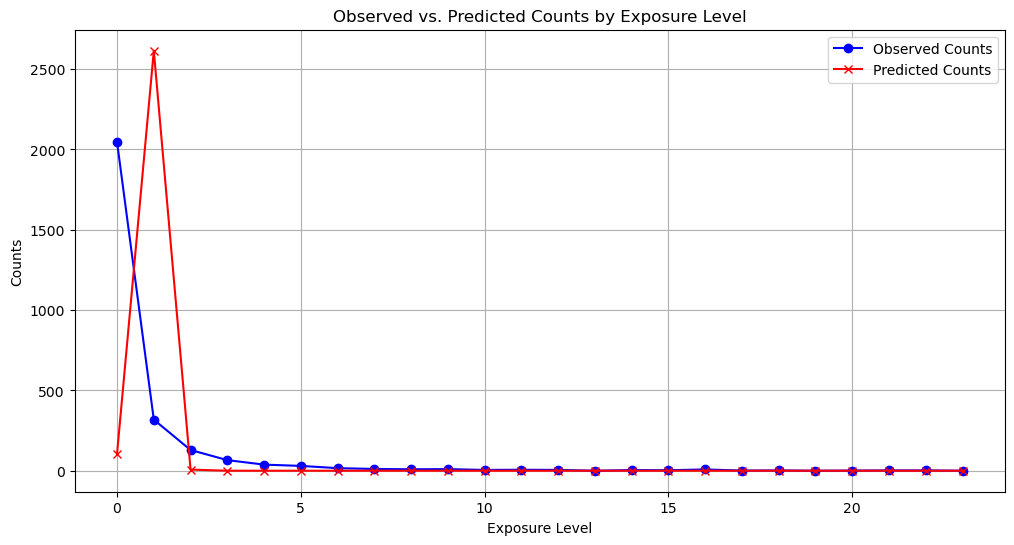

In [16]:
# Graph the original and predicted numbers of exposures. 
plt.figure(figsize=(12, 6))
plt.plot(results_df['Exposure Level'], results_df['Observed Counts'], marker='o', label='Observed Counts', color='blue')
plt.plot(results_df['Exposure Level'], results_df['Predicted Counts'], marker='x', label='Predicted Counts', color='red')
plt.xlabel('Exposure Level')
plt.ylabel('Counts')
plt.title('Observed vs. Predicted Counts by Exposure Level')
plt.legend()
plt.grid(True)
plt.show()

In [17]:
y = data['NumberofVisits']
X = data[['LnInc', 'Sex', 'LnAge', 'HHSize']]
X = sm.add_constant(X)  # Add intercept

# Fit the Negative Binomial model using the discrete model instead of GLM to estimate alpha
from statsmodels.discrete.discrete_model import NegativeBinomial
nb_model = NegativeBinomial(y, X).fit()

# Print the model summary to see the estimated parameters, including alpha
print(nb_model.summary())



Optimization terminated successfully.
         Current function value: 1.059005
         Iterations: 34
         Function evaluations: 45
         Gradient evaluations: 45
                     NegativeBinomial Regression Results                      
Dep. Variable:         NumberofVisits   No. Observations:                 2728
Model:               NegativeBinomial   Df Residuals:                     2723
Method:                           MLE   Df Model:                            4
Date:                Tue, 24 Mar 2026   Pseudo R-squ.:                0.005733
Time:                        21:59:42   Log-Likelihood:                -2889.0
converged:                       True   LL-Null:                       -2905.6
Covariance Type:            nonrobust   LLR p-value:                 1.029e-06
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -4.0824      1.158     -

In [18]:
# Predict expected counts (exposure) for each individual
predicted_counts = nb_model.predict(X)

# Create an array of exposure levels from 0 to 23
exposure_levels = np.arange(0, 24)

# For each exposure level, calculate the predicted number of people
predicted_people_by_level = []
for level in exposure_levels:
    prob_level = nb_model.predict(np.array([level]))  # Probability of observing each level
    predicted_people_by_level.append(np.sum(predicted_counts * prob_level))


# Convert to DataFrame for better visualization
prediction_results = pd.DataFrame({
    'Exposure Level': exposure_levels,
    'Predicted People': predicted_people_by_level
})

print(prediction_results)


    Exposure Level  Predicted People
0                0      2.643967e+03
1                1      4.459595e+01
2                2      7.522028e-01
3                3      1.268745e-02
4                4      2.140001e-04
5                5      3.609553e-06
6                6      6.088256e-08
7                7      1.026910e-09
8                8      1.732096e-11
9                9      2.921537e-13
10              10      4.927775e-15
11              11      8.311710e-17
12              12      1.401941e-18
13              13      2.364664e-20
14              14      3.988493e-22
15              15      6.727417e-24
16              16      1.134718e-25
17              17      1.913936e-27
18              18      3.228248e-29
19              19      5.445106e-31
20              20      9.184295e-33
21              21      1.549121e-34
22              22      2.612912e-36
23              23      4.407216e-38


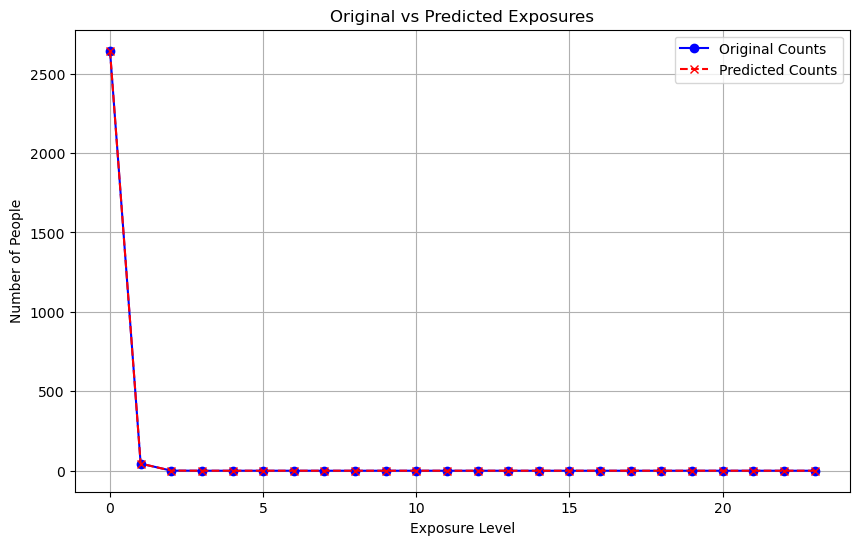

In [19]:
# Original Exposure Counts (replace with your actual observed data)
original_counts = predicted_people_by_level 

# Plotting the original and predicted numbers of exposures
plt.figure(figsize=(10, 6))

# Plot original counts
plt.plot(exposure_levels, original_counts, label='Original Counts', marker='o', linestyle='-', color='blue')

# Plot predicted counts
plt.plot(exposure_levels, prediction_results['Predicted People'], label='Predicted Counts', marker='x', linestyle='--', color='red')

# Add labels and title
plt.xlabel('Exposure Level')
plt.ylabel('Number of People')
plt.title('Original vs Predicted Exposures')
plt.legend()

# Display the plot
plt.grid(True)
plt.show()

This section was omitted due to unavailable data. The remaining analysis focuses on the core models and results.


In [24]:
# Load the books01.csv data
books01_data = pd.read_csv('books01.csv')

# Expand each row according to 'num_people' count
books01_expanded = books01_data.loc[books01_data.index.repeat(books01_data['num_people'])].reset_index(drop=True)

# Set up the model without weights
Y_expanded = books01_expanded['num_purchases']  # Dependent variable
X_expanded = np.ones(len(Y_expanded))  # Only intercept

# Fit the Poisson model
poisson_model_expanded = sm.GLM(Y_expanded, X_expanded, family=sm.families.Poisson()).fit()

# Display summary and max log-likelihood
print(poisson_model_expanded.summary())
print("Maximum log-likelihood:", poisson_model_expanded.llf)

                 Generalized Linear Model Regression Results                  
Dep. Variable:          num_purchases   No. Observations:                 1812
Model:                            GLM   Df Residuals:                     1811
Model Family:                 Poisson   Df Model:                            0
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -7237.9
Date:                Tue, 24 Mar 2026   Deviance:                       9481.8
Time:                        22:06:18   Pearson chi2:                 2.20e+04
No. Iterations:                     5   Pseudo R-squ. (CS):              0.000
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.3620      0.012    114.553      0.0

In [25]:
# Load the books02.csv data
books02_data = pd.read_csv('books02.csv')

# Step 1: Aggregate total purchases for each user
books02_agg = books02_data.groupby('userid')['bn_purchase_count'].sum().reset_index()
Y = books02_agg['bn_purchase_count']  # Number of purchases for each user

# Step 2: Add an intercept only, ignoring other variables
X = np.ones(len(Y))  # Only an intercept, no independent variables

# Step 3: Fit the Poisson model using GLM
poisson_model_books02 = sm.GLM(Y, X, family=sm.families.Poisson()).fit()

# Display estimated parameters and log-likelihood
print(poisson_model_books02.summary())
print("Maximum log-likelihood:", poisson_model_books02.llf)

# Print AIC and BIC values
aic_value = poisson_model_books02.aic
bic_value = poisson_model_books02.bic

print("AIC:", aic_value)
print("BIC:", bic_value)

                 Generalized Linear Model Regression Results                  
Dep. Variable:      bn_purchase_count   No. Observations:                 1812
Model:                            GLM   Df Residuals:                     1811
Model Family:                 Poisson   Df Model:                            0
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -7237.9
Date:                Tue, 24 Mar 2026   Deviance:                       9481.8
Time:                        22:07:31   Pearson chi2:                 2.20e+04
No. Iterations:                     5   Pseudo R-squ. (CS):              0.000
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.3620      0.012    114.553      0.0

/opt/anaconda3/lib/python3.13/site-packages/statsmodels/genmod/generalized_linear_model.py:1923: FutureWarning: The bic value is computed using the deviance formula. After 0.13 this will change to the log-likelihood based formula. This change has no impact on the relative rank of models compared using BIC. You can directly access the log-likelihood version using the `bic_llf` attribute. You can suppress this message by calling statsmodels.genmod.generalized_linear_model.SET_USE_BIC_LLF with True to get the LLF-based version now or False to retainthe deviance version.
  warnings.warn(


In [26]:
#Predict the number of people with 0, …, 20 exposures based on the Poisson regression 

# Fit the Poisson regression model
poisson_model = sm.GLM(Y, X, family=sm.families.Poisson()).fit()

# Generate predictions for each level from 0 to 20
exposure_counts = np.arange(0, 21)  # Exposure levels from 0 to 20
predicted_counts = poisson_model.predict(X).round()  # Predicted number of visits per individual

# Sum predicted counts for each level from 0 to 20 for total population prediction
predicted_counts_by_level = [np.sum(predicted_counts == i) for i in exposure_counts]

# Calculate observed counts for each exposure level
observed_counts_by_level = [np.sum(Y == i) for i in exposure_counts]

results_df = pd.DataFrame({
    'Exposure Level': exposure_counts,
    'Predicted Counts': predicted_counts_by_level,
    'Observed Counts': observed_counts_by_level
})

# Display the results in tabular format
print(results_df)

    Exposure Level  Predicted Counts  Observed Counts
0                0                 0                0
1                1                 0              753
2                2                 0              362
3                3                 0              175
4                4              1812              126
5                5                 0               82
6                6                 0               74
7                7                 0               30
8                8                 0               48
9                9                 0               31
10              10                 0               20
11              11                 0               12
12              12                 0               12
13              13                 0               11
14              14                 0                3
15              15                 0                6
16              16                 0                8
17              17          

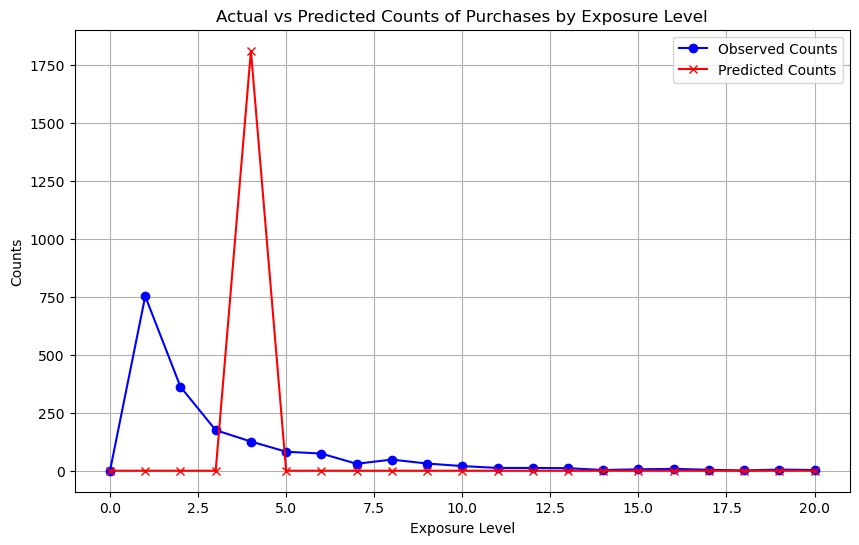

In [27]:
#Graph the original and predicted number of purchases.

# Plotting the Actual vs Predicted Counts
plt.figure(figsize=(10, 6))
plt.plot(results_df['Exposure Level'], results_df['Observed Counts'], label='Observed Counts', marker='o', color='blue')
plt.plot(results_df['Exposure Level'], results_df['Predicted Counts'], label='Predicted Counts', marker='x', color='red')

# Add labels and title
plt.xlabel('Exposure Level')
plt.ylabel('Counts')
plt.title('Actual vs Predicted Counts of Purchases by Exposure Level')
plt.legend()
plt.grid(True)

# Show the plot
plt.show()



In [28]:
nb_model = NegativeBinomial(Y_expanded, X_expanded).fit()

# Print the model summary to see the estimated parameters, including alpha
print(nb_model.summary())

# Extract the dispersion parameter (r) and mean (mu) from the model
r = nb_model.scale  # Dispersion parameter (alpha)
mu = nb_model.params['const']  # The mean (μ) based on the intercept

# Calculate the probability of success (p) using the formula p = r / (r + mu)
p = r / (r + mu)

# Print the results
print(f"r = {r}")
print(f"p = {p}")


Optimization terminated successfully.
         Current function value: 2.474157
         Iterations: 5
         Function evaluations: 6
         Gradient evaluations: 6
                     NegativeBinomial Regression Results                      
Dep. Variable:          num_purchases   No. Observations:                 1812
Model:               NegativeBinomial   Df Residuals:                     1811
Method:                           MLE   Df Model:                            0
Date:                Tue, 24 Mar 2026   Pseudo R-squ.:               4.306e-12
Time:                        22:07:48   Log-Likelihood:                -4483.2
converged:                       True   LL-Null:                       -4483.2
Covariance Type:            nonrobust   LLR p-value:                       nan
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.3620      0.025     55.5

In [29]:
nb_model = NegativeBinomial(Y, X).fit()

# Print the model summary to see the estimated parameters, including alpha
print(nb_model.summary())

# Extract the dispersion parameter (r) and mean (mu) from the model
r = nb_model.scale  # Dispersion parameter (alpha)
mu = nb_model.params['const']  # The mean (μ) based on the intercept

# Calculate the probability of success (p) using the formula p = r / (r + mu)
p = r / (r + mu)

# Print the results
print(f"r = {r}")
print(f"p = {p}")

# Print AIC and BIC values
aic_value = nb_model.aic
bic_value = nb_model.bic

print("AIC:", aic_value)
print("BIC:", bic_value)

Optimization terminated successfully.
         Current function value: 2.474157
         Iterations: 5
         Function evaluations: 6
         Gradient evaluations: 6
                     NegativeBinomial Regression Results                      
Dep. Variable:      bn_purchase_count   No. Observations:                 1812
Model:               NegativeBinomial   Df Residuals:                     1811
Method:                           MLE   Df Model:                            0
Date:                Tue, 24 Mar 2026   Pseudo R-squ.:               4.306e-12
Time:                        22:07:51   Log-Likelihood:                -4483.2
converged:                       True   LL-Null:                       -4483.2
Covariance Type:            nonrobust   LLR p-value:                       nan
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.3620      0.025     55.5

In [30]:
# Array of exposure levels (0 to 20, and 20+ as 21)
exposure_levels = np.arange(0, 22)  # 0 to 21 (where 21 represents 20+)

observed_counts = books02_data['bn_purchase_count'].head(22)

# Calculate the predicted number of people for each exposure level
predicted_counts_by_level = []

for level in exposure_levels:
    if level < 20:
        # Calculate the probability for this exact level
        prob_level = nbinom.pmf(level, r, p)
    else:
        # For 20+ exposures, sum the probabilities of 20, 21, 22, ...
        prob_level = 1 - nbinom.cdf(19, r, p)
    
    # Predicted number of people with this exposure level
    predicted_counts = np.sum(observed_counts) * prob_level  # Scale to match population size
    predicted_counts_by_level.append(predicted_counts)

# Convert to DataFrame for visualization
prediction_results = pd.DataFrame({
    'Exposure Level': exposure_levels,
    'Observed Counts': observed_counts,
    'Predicted Counts': predicted_counts_by_level
})

print(prediction_results)

    Exposure Level  Observed Counts  Predicted Counts
0                0                4         55.461593
1                1               13         31.980766
2                2                1         18.441039
3                3                4         10.633639
4                4                3          6.131665
5                5                2          3.535696
6                6                1          2.038785
7                7                1          1.175623
8                8                2          0.677898
9                9                1          0.390896
10              10                2          0.225402
11              11                5          0.129973
12              12                5          0.074946
13              13                1          0.043216
14              14                1          0.024920
15              15               39          0.014369
16              16                4          0.008286
17              17          

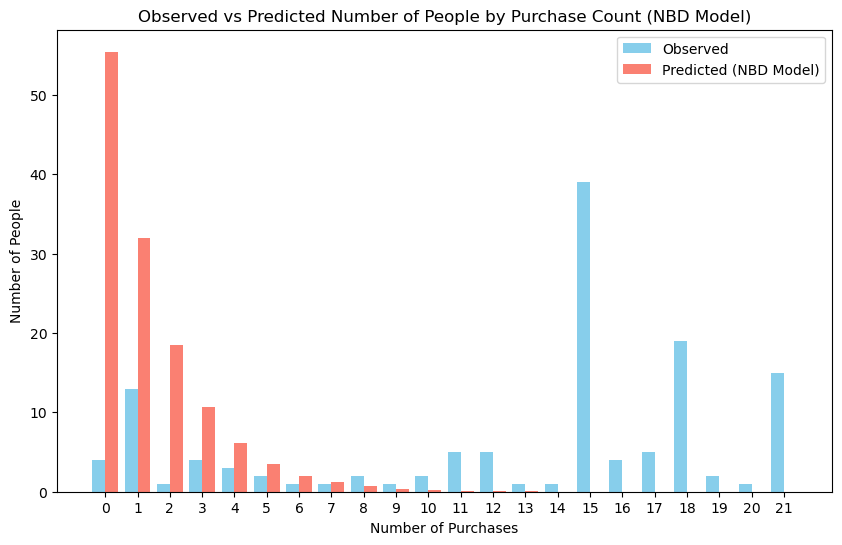

In [31]:
# Plotting both observed and predicted counts
plt.figure(figsize=(10, 6))
plt.bar(prediction_results['Exposure Level'] - 0.2, prediction_results['Observed Counts'], width=0.4, label='Observed', color='skyblue')
plt.bar(prediction_results['Exposure Level'] + 0.2, prediction_results['Predicted Counts'], width=0.4, label='Predicted (NBD Model)', color='salmon')
plt.xlabel("Number of Purchases")
plt.ylabel("Number of People")
plt.title("Observed vs Predicted Number of People by Purchase Count (NBD Model)")
plt.xticks(prediction_results['Exposure Level'])
plt.legend()
plt.show()


In [32]:

# Calculate the probability of zero events
p_zero = (1 - p) ** r

# Calculate reach
reach = 1 - p_zero
print("Reach:", reach)

# Calculate average frequency
average_frequency = (p * r) / (1 - p)
print("Average Frequency:", average_frequency)

# Calculate GRPs
grps = reach * average_frequency
print("GRPs:", grps)

Reach: 0.42337094255728824
Average Frequency: 0.7342171489499559
GRPs: 0.31084620639266775


In [33]:
#Identify all independent variables with missing values.

# Drop the dependent variable column to isolate only independent variables
independent_vars = books02_data.drop(columns=['bn_purchase_count']) 

# Check for missing values in independent variables
missing_values = independent_vars.isnull().sum()

# Filter to show only columns with missing values
missing_independent_vars = missing_values[missing_values > 0]

# Print the result
print("Independent variables with missing values:")
print(missing_independent_vars)

Independent variables with missing values:
education    1337
region          2
age             1
dtype: int64


In [34]:
# Drop any variable with many missing values (education). 
books02_cleaned = books02_data.drop(columns=['education']) 
print(books02_cleaned)

        userid  region  hhsz   age  income  child  race  country  \
0     13503636     3.0     4   8.0       7      1     1        1   
1     14559596     4.0     2  10.0       5      1     1        0   
2     14594414     3.0     3   8.0       7      1     1        0   
3     14621501     1.0     2   6.0       3      0     1        0   
4     14796973     1.0     2   3.0       3      0     1        0   
...        ...     ...   ...   ...     ...    ...   ...      ...   
1807   9956411     4.0     2   9.0       5      0     1        1   
1808  13525346     3.0     2   2.0       1      0     1        1   
1809  14154447     2.0     3   6.0       2      1     1        0   
1810  14563861     1.0     2   8.0       5      1     1        0   
1811  15388955     3.0     3   7.0       5      1     1        0   

      bn_purchase_count  
0                     4  
1                    13  
2                     1  
3                     4  
4                     3  
...                 ...  
1

In [35]:
#If the number of missing values is small (age,region), delete the rows involved 
columns_to_check = ['age', 'region']  

# Drop rows with missing values in only the specified columns
books02_cleaned = books02_cleaned.dropna(subset=columns_to_check)

# Print the shape to verify the number of rows after dropping
print(books02_cleaned)


        userid  region  hhsz   age  income  child  race  country  \
0     13503636     3.0     4   8.0       7      1     1        1   
1     14559596     4.0     2  10.0       5      1     1        0   
2     14594414     3.0     3   8.0       7      1     1        0   
3     14621501     1.0     2   6.0       3      0     1        0   
4     14796973     1.0     2   3.0       3      0     1        0   
...        ...     ...   ...   ...     ...    ...   ...      ...   
1807   9956411     4.0     2   9.0       5      0     1        1   
1808  13525346     3.0     2   2.0       1      0     1        1   
1809  14154447     2.0     3   6.0       2      1     1        0   
1810  14563861     1.0     2   8.0       5      1     1        0   
1811  15388955     3.0     3   7.0       5      1     1        0   

      bn_purchase_count  
0                     4  
1                    13  
2                     1  
3                     4  
4                     3  
...                 ...  
1

In [36]:
# Verify that there are no missing values left in these columns
print("Missing values in specified columns after dropna():")
print(books02_cleaned[columns_to_check].isnull().sum())


Missing values in specified columns after dropna():
age       0
region    0
dtype: int64


In [37]:
#For the remaining variables, replace the missing values with the means of the corresponding variables. 
books02_cleaned = books02_cleaned.fillna(books02_cleaned.mean())

# Verify that there are no missing values left
print("Missing values after filling with means:")
print(books02_cleaned.isnull().sum())

Missing values after filling with means:
userid               0
region               0
hhsz                 0
age                  0
income               0
child                0
race                 0
country              0
bn_purchase_count    0
dtype: int64


In [38]:
# Incorporate all the available customer characteristics and estimate all relevant parameters for Poisson regression using MLE.
# Define the dependent variable (Y) and independent variables (X)
Y = books02_cleaned['bn_purchase_count']  
X = books02_cleaned.drop(columns=['bn_purchase_count', 'userid'])  # Drop the dependent variable to get all characteristics

# Add a constant term for the intercept
X = sm.add_constant(X)

# Fit the Poisson regression model using Maximum Likelihood Estimation
poisson_model = sm.GLM(Y, X, family=sm.families.Poisson()).fit()

# Print the model summary to see estimated parameters
print(poisson_model.summary())

# Print AIC and BIC values
aic_value = poisson_model.aic
bic_value = poisson_model.bic

print("AIC:", aic_value)
print("BIC:", bic_value)

                 Generalized Linear Model Regression Results                  
Dep. Variable:      bn_purchase_count   No. Observations:                 1809
Model:                            GLM   Df Residuals:                     1801
Model Family:                 Poisson   Df Model:                            7
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -7194.9
Date:                Tue, 24 Mar 2026   Deviance:                       9403.8
Time:                        22:08:24   Pearson chi2:                 2.13e+04
No. Iterations:                     5   Pseudo R-squ. (CS):            0.04032
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.3226      0.075     17.532      0.0

/opt/anaconda3/lib/python3.13/site-packages/statsmodels/genmod/generalized_linear_model.py:1923: FutureWarning: The bic value is computed using the deviance formula. After 0.13 this will change to the log-likelihood based formula. This change has no impact on the relative rank of models compared using BIC. You can directly access the log-likelihood version using the `bic_llf` attribute. You can suppress this message by calling statsmodels.genmod.generalized_linear_model.SET_USE_BIC_LLF with True to get the LLF-based version now or False to retainthe deviance version.
  warnings.warn(


In [39]:
#Predict the number of people with 0, …, 20, 20+ purchases based on the Poisson regression

# Generate predictions (expected purchase count) for each individual using the model
predicted_means = poisson_model.predict(X)  # `X` includes all customer characteristics

# Define purchase count levels of interest
purchase_levels = np.arange(0, 21)  # Levels from 0 to 20

observed_counts = books02_cleaned['bn_purchase_count'].head(22)

# Calculate the predicted number of people for each purchase level
predicted_people_by_level = []

for level in purchase_levels:
    # Calculate probability for each individual for the specific purchase count level
    prob_level = poisson.pmf(level, predicted_means)
    
    # Sum the probabilities to estimate the total number of people at this purchase count level
    predicted_people_by_level.append(np.sum(prob_level))

# Calculate the predicted number of people with 20+ purchases
# Sum probabilities for purchase counts 20 and above
prob_20_plus = np.sum(1 - poisson.cdf(20, predicted_means))
predicted_people_by_level.append(prob_20_plus)

# Create a DataFrame to display the results
prediction_results = pd.DataFrame({
    'Purchase Count': list(purchase_levels) + ['20+'],
     'Observed Count': observed_counts,
    'Predicted People': predicted_people_by_level
})

print(prediction_results)


   Purchase Count  Observed Count  Predicted People
0               0               4         39.693780
1               1              13        147.740125
2               2               1        279.216874
3               3               4        356.600529
4               4               3        345.690196
5               5               2        270.949673
6               6               1        178.643795
7               7               1        101.801006
8               8               2         51.135600
9               9               1         22.981557
10             10               2          9.349759
11             11               5          3.475991
12             12               5          1.190101
13             13               1          0.377695
14             14               1          0.111727
15             15              39          0.030953
16             16               4          0.008065
17             17               5          0.001983
18          

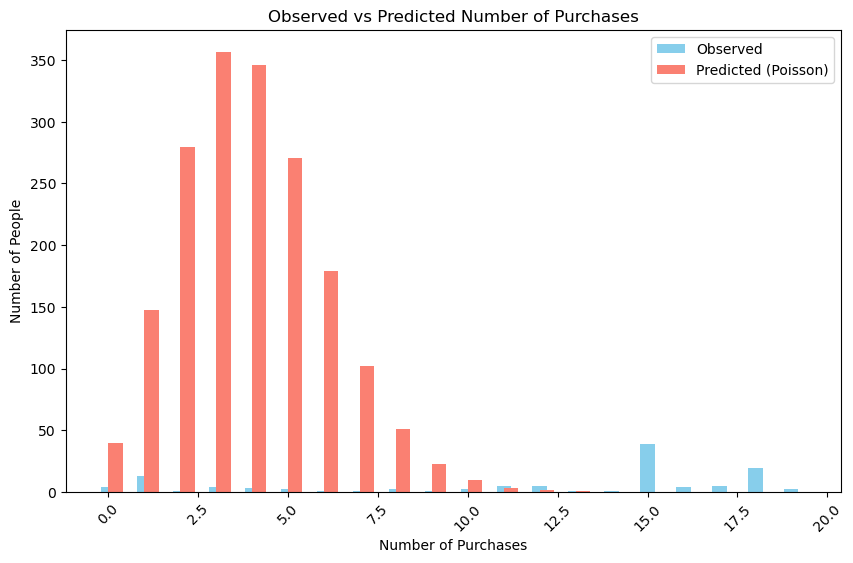

In [40]:
# Graph the original and predicted number of purchases 
# Create a list of purchase levels (from 0 to 20 and 20+)
purchase_levels = np.arange(0, 21)
purchase_levels = list(purchase_levels) + ['20+']


# Adding predicted counts for 20+ (based on your previous code)
predicted_people_by_level.append(np.sum(1 - poisson.cdf(20, predicted_means)))  # Predicted for 20+ purchases

# Create the plot
plt.figure(figsize=(10, 6))

# Plot observed data (use bars for actual data)
plt.bar(purchase_levels[:20], observed_counts[:20], width=0.4, label='Observed', color='skyblue', align='center')

# Plot predicted data (use bars for predicted data)
plt.bar(purchase_levels[:20], predicted_people_by_level[:20], width=0.4, label='Predicted (Poisson)', color='salmon', align='edge')

# Add labels and title
plt.xlabel("Number of Purchases")
plt.ylabel("Number of People")
plt.title("Observed vs Predicted Number of Purchases")
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.legend()

# Show the plot
plt.show()



In [41]:
#Estimate all relevant parameters for NBD regression using MLE
nb_model = NegativeBinomial(Y, X).fit()

# Print the model summary to see the estimated parameters, including alpha
print(nb_model.summary())

# Print AIC and BIC values
aic_value = nb_model.aic
bic_value = nb_model.bic

print("AIC:", aic_value)
print("BIC:", bic_value)

Optimization terminated successfully.
         Current function value: 2.469919
         Iterations: 19
         Function evaluations: 25
         Gradient evaluations: 25
                     NegativeBinomial Regression Results                      
Dep. Variable:      bn_purchase_count   No. Observations:                 1809
Model:               NegativeBinomial   Df Residuals:                     1801
Method:                           MLE   Df Model:                            7
Date:                Tue, 24 Mar 2026   Pseudo R-squ.:                0.001981
Time:                        22:08:33   Log-Likelihood:                -4468.1
converged:                       True   LL-Null:                       -4477.0
Covariance Type:            nonrobust   LLR p-value:                   0.01321
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.3140      0.148      

In [42]:
#Predict the number of people with 0, …, 20, 20+ purchases based on the NBD regression.
# Extract the dispersion parameter (r) and mean (mu) from the model
r = nb_model.scale  # Dispersion parameter (alpha)
mu = nb_model.params['const']  # The mean (μ) based on the intercept 

# Calculate the probability of success (p) using the formula p = r / (r + mu)
p = r / (r + mu)

# Print the results
print(f"r = {r}")
print(f"p = {p}")

exposure_levels = np.arange(0, 22)  # 0 to 21 (where 21 represents 20+)

observed_counts = books02_cleaned['bn_purchase_count'].head(22)

# Calculate the predicted number of people for each exposure level
predicted_counts_by_level = []

for level in exposure_levels:
    if level < 20:
        # Calculate the probability for this exact level
        prob_level = nbinom.pmf(level, r, p)
    else:
        # For 20+ exposures, sum the probabilities of 20, 21, 22, ...
        prob_level = 1 - nbinom.cdf(19, r, p)
    
    # Predicted number of people with this exposure level
    predicted_counts = np.sum(observed_counts) * prob_level  # Scale to match population size
    predicted_counts_by_level.append(predicted_counts)

# Convert to DataFrame for visualization
prediction_results = pd.DataFrame({
    'Exposure Level': exposure_levels,
    'Observed Counts': observed_counts,
    'Predicted Counts': predicted_counts_by_level
})

print(prediction_results)

r = 1.0
p = 0.43215025264850365
    Exposure Level  Observed Counts  Predicted Counts
0                0                4         56.611683
1                1               13         32.146930
2                2                1         18.254626
3                3                4         10.365885
4                4                3          5.886265
5                5                2          3.342514
6                6                1          1.898046
7                7                1          1.077805
8                8                2          0.612031
9                9                1          0.347542
10              10                2          0.197352
11              11                5          0.112066
12              12                5          0.063637
13              13                1          0.036136
14              14                1          0.020520
15              15               39          0.011652
16              16                4          0.006

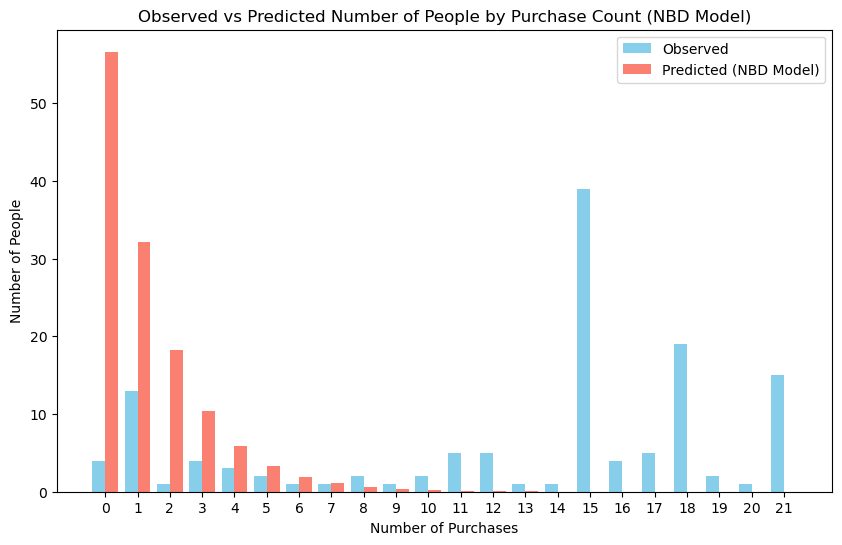

In [43]:
#Graph the original and predicted number of purchases. 
plt.figure(figsize=(10, 6))
plt.bar(prediction_results['Exposure Level'] - 0.2, prediction_results['Observed Counts'], width=0.4, label='Observed', color='skyblue')
plt.bar(prediction_results['Exposure Level'] + 0.2, prediction_results['Predicted Counts'], width=0.4, label='Predicted (NBD Model)', color='salmon')
plt.xlabel("Number of Purchases")
plt.ylabel("Number of People")
plt.title("Observed vs Predicted Number of People by Purchase Count (NBD Model)")
plt.xticks(prediction_results['Exposure Level'])
plt.legend()
plt.show()


## Conclusion

## Conclusion

This project compared Poisson and Negative Binomial models for analyzing customer behavior. The results showed that regression-based models provided a better fit than simpler baseline models, and the Negative Binomial approach was more effective in handling variability in the data.

Overall, the analysis demonstrates how statistical modeling can be used to generate insights into customer behavior and support data-driven decision-making in marketing and demand forecasting.